# HGQA Demo: EV Charging Station Placement

This notebook runs the full HGQA pipeline on a small synthetic instance. The goal is to place three new EV charging stations on a 5×5 city grid, given existing charger coverage, gas station locations, and a set of points of interest (POIs) with population densities. The pipeline goes from raw data to a ranked shortlist of placement candidates, passing through QUBO construction, cell pruning, and exact combinatorial search. No external data files are needed: all inputs are generated in the next cell.

In [1]:
import sys
import os

# Add src/ to path so local modules resolve without package installation.
# Works whether the notebook is opened from hgqa-submission/ or its parent.
sys.path.insert(0, 'src')
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'src'))

import numpy as np
import matplotlib.pyplot as plt
from math import comb

from helpers import divide_graph_into_parts, calculate_cell_weights, suggest_parameters
from qubo_builder import build_qubo, evaluate_solution, brute_force_ranking
from cell_pruner import prune_cells, remap_qubo_for_qaoa, translate_results

print('Imports OK')

Imports OK


In [2]:
# ── Synthetic city data (5×5 grid, 0–10 coordinate space) ──
#
# POIs: (x, y, density).  Density in [0, 1], higher = more demand.
# Two dense clusters: bottom-left and top-right.
points_of_interest = [
    # Bottom-left cluster
    (1.2, 1.5, 0.9),
    (2.0, 1.8, 0.7),
    (1.5, 2.5, 0.6),
    (2.5, 2.0, 0.5),
    # Top-right cluster
    (7.5, 7.8, 0.85),
    (8.2, 8.0, 0.80),
    (7.0, 8.5, 0.65),
    # Mid-grid isolated POI
    (5.0, 5.0, 0.40),
    # Low-density scatter
    (3.5, 6.0, 0.20),
    (6.5, 3.0, 0.30),
]

# Existing chargers already serving the bottom-left cluster
existing_chargers = [
    (1.8, 1.8),
    (5.5, 5.5),
]

# Gas stations: potential co-location sites
gas_stations = [
    (7.8, 8.2),
    (3.0, 3.0),
]

X_MIN, X_MAX = 0.0, 10.0
Y_MIN, Y_MAX = 0.0, 10.0
N_QUBITS = 25   # 5×5 grid
M = 3            # new chargers to place

print(f'POIs: {len(points_of_interest)}')
print(f'Existing chargers: {len(existing_chargers)}')
print(f'Gas stations: {len(gas_stations)}')
print(f'Grid: {N_QUBITS} cells ({int(N_QUBITS**0.5)}×{int(N_QUBITS**0.5)}),  m={M} new chargers')

POIs: 10
Existing chargers: 2
Gas stations: 2
Grid: 25 cells (5×5),  m=3 new chargers


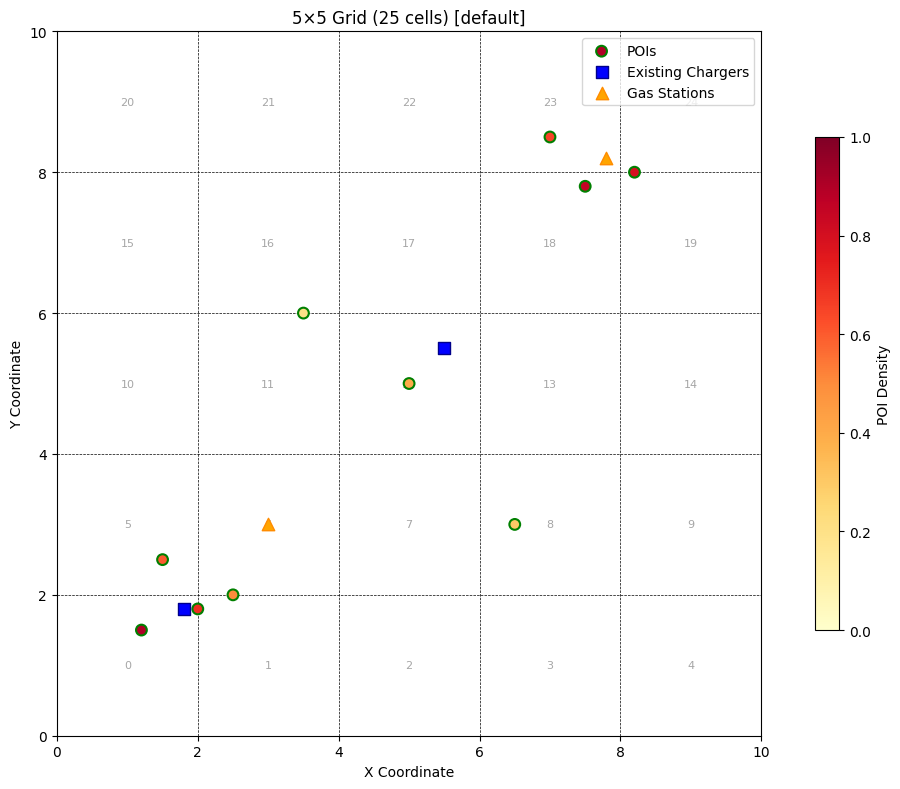

  Grid Info:
    Grid    0 (row=0, col=0): 1 POI(s) [densities: 0.90] | 1 charger(s)
    Grid    1 (row=0, col=1): 1 POI(s) [densities: 0.70]
    Grid    5 (row=1, col=0): 1 POI(s) [densities: 0.60]
    Grid    6 (row=1, col=1): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid    8 (row=1, col=3): 1 POI(s) [densities: 0.30]
    Grid   12 (row=2, col=2): 1 POI(s) [densities: 0.40] | 1 charger(s)
    Grid   16 (row=3, col=1): 1 POI(s) [densities: 0.20]
    Grid   18 (row=3, col=3): 1 POI(s) [densities: 0.85]
    Grid   23 (row=4, col=3): 1 POI(s) [densities: 0.65] | 1 gas station(s)
    Grid   24 (row=4, col=4): 1 POI(s) [densities: 0.80]

Cell weights (cells with POIs, chargers, or gas stations):
 Cell ID  POIs     Raw    Norm   Weight   Gas  Ex.Ch
-------------------------------------------------------
       0     1   0.900   1.000    5.000     0      1
       1     1   0.700   0.778    3.889     0      0
       5     1   0.600   0.667    3.333     0      0
       6     1   0.50

In [3]:
# ── Grid construction and weight calculation ──

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX,
    y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_chargers,
    gas_stations=gas_stations,
    grid_division='default',
)

cell_weights = calculate_cell_weights(grid_details, scale_factor=5.0, min_weight=0.5)
plt.show()

# Grid data table (non-empty cells only)
print('\nCell weights (cells with POIs, chargers, or gas stations):')
print(f'{"Cell ID":>8} {"POIs":>5} {"Raw":>7} {"Norm":>7} {"Weight":>8} {"Gas":>5} {"Ex.Ch":>6}')
print('-' * 55)
for gid in sorted(grid_details.keys()):
    info = grid_details[gid]
    w = cell_weights[gid]
    if w['weight'] > 0 or info['num_gas_stations'] > 0 or info['num_existing_chargers'] > 0:
        print(f'{gid:>8} {info["num_pois"]:>5} {w["raw_score"]:>7.3f} '
              f'{w["normalized_score"]:>7.3f} {w["weight"]:>8.3f} '
              f'{info["num_gas_stations"]:>5} {info["num_existing_chargers"]:>6}')

In [4]:
# ── QUBO construction ──

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
radii  = params['radii']
alpha  = params['alpha']
intra  = params['intra']
lam    = params['lambda']

print('Suggested parameters:')
print(f'  Radii  R1={radii["R1"]} Rs={radii["Rs"]} R3={radii["R3"]} R4={radii["R4"]} R6={radii["R6"]}')
print(f'  Alpha  a1={alpha["a1"]:.2f}  a2={alpha["a2"]:.2f}  a3={alpha["a3"]:.2f}  '
      f'a4={alpha["a4"]:.2f}  a5={alpha["a5"]:.2f}  a6={alpha["a6"]:.2f}')
print(f'  Lambda {lam:.2f}')

Q_obj, h5_params, diags = build_qubo(
    grid_details=grid_details,
    cell_weights=cell_weights,
    plot_deets=plot_deets,
    m=M,
    alpha1=alpha['a1'], alpha2=alpha['a2'], alpha3=alpha['a3'],
    alpha4=alpha['a4'], alpha5=alpha['a5'], alpha6=alpha['a6'],
    beta=intra['beta'], gamma=intra['gamma'],
    delta=intra['delta'], epsilon=intra['epsilon'],
    lam=lam,
    R1=radii['R1'], Rs=radii['Rs'], R3=radii['R3'],
    R4=radii['R4'], R6=radii['R6'],
)

N = plot_deets['total_cells']
diag_vals    = [Q_obj.get((i, i), 0.0) for i in range(N)]
offdiag_vals = [v for (i, j), v in Q_obj.items() if i != j]

print(f'\nQ matrix:  {N}×{N},  {len(Q_obj)} non-zero entries')
print(f'  Diagonal:    [{min(diag_vals):.4f}, {max(diag_vals):.4f}]')
if offdiag_vals:
    print(f'  Off-diagonal: [{min(offdiag_vals):.4f}, {max(offdiag_vals):.4f}]')
    print(f'  Sparsity:     {1.0 - len(Q_obj)/(N*N):.1%}')
else:
    print('  No off-diagonal entries (radius cutoffs exceed grid span for this tiny instance)')

Suggested parameters:
  Radii  R1=2 Rs=2 R3=1 R4=2 R6=1
  Alpha  a1=3.00  a2=1.00  a3=1.19  a4=0.50  a5=1.00  a6=0.17
  Lambda 60.00

Q matrix:  25×25,  193 non-zero entries
  Diagonal:    [-3.3864, -0.2520]
  Off-diagonal: [0.0093, 0.9974]
  Sparsity:     69.1%


In [5]:
# ── Cell pruner ──

surviving_cells, report = prune_cells(
    Q_obj=Q_obj,
    N=N,
    m=M,
    num_cols=plot_deets['num_cols'],
    R4=radii['R4'],
    tier3_keep=3,
    verbose=True,
)

K = len(surviving_cells)
search_before = comb(N, M)
search_after  = comb(K, M)
print(f'\nPruned: {N} → {K} cells  ({100*(1-K/N):.0f}% reduction)')
print(f'Search space: C({N},{M})={search_before:,} → C({K},{M})={search_after:,}')
if search_after > 0:
    print(f'Reduction factor: {search_before/search_after:.1f}×')

CELL PRUNING
  Starting cells: 25
  Solo scores: 25 negative, 0 zero, 0 positive
  Solo range: [-3.3864, -0.2520]

  Tier 1 (dead cells): 0 pruned, 25 remain  (0 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 14 pruned, 11 remain  (ref score=-7.6163)
  Tier 3 (dedup):      0 pruned, 11 remain  (11 clusters, sizes=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

  RESULT: 25 → 11 cells (56% reduction)
  Surviving IDs: [0, 1, 5, 6, 12, 14, 18, 19, 22, 23, 24]
  Solo scores: [np.float64(-1.8775), np.float64(-1.7713), np.float64(-1.5515), np.float64(-2.4562), np.float64(-1.81), np.float64(-1.6344), np.float64(-2.771), np.float64(-1.9355), np.float64(-1.732), np.float64(-3.3864), np.float64(-2.4105)]

Pruned: 25 → 11 cells  (56% reduction)
Search space: C(25,3)=2,300 → C(11,3)=165
Reduction factor: 13.9×


In [6]:
# ── Exact small-instance solver (statevector-equivalent ground truth) ──
#
# For K <= ~20, exhaustive enumeration over C(K, m) solutions is equivalent
# to reading the complete statevector after QAOA optimization. Both give a
# full ranking of every feasible placement with no approximation.

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)

print(f'Pruned Q: {len(Q_pruned)} non-zero entries over {K} qubits')
print(f'Enumerating all C({K},{M}) = {comb(K,M):,} feasible solutions...')

# brute_force_ranking returns List[(score, solution_tuple)] in qubit-index space
bf_raw = brute_force_ranking(Q_pruned, K, M, top_k=M + 3)

# translate_results expects (score, [qubit_ids], probability) — add 0.0 as placeholder
bf_formatted = [(score, list(qubits), 0.0) for score, qubits in bf_raw]
translated   = translate_results(bf_formatted, qubit_to_cell)

print(f'\nTop-{len(translated)} solutions (QUBO score, lower is better):')
print(f'{"Rank":>5}  {"Score":>9}  Cell IDs (original grid)')
print('-' * 45)
for rank, (score, cell_ids, _) in enumerate(translated, 1):
    print(f'{rank:>5}  {score:>9.4f}  {sorted(cell_ids)}')

Pruned Q: 43 non-zero entries over 11 qubits
Enumerating all C(11,3) = 165 feasible solutions...

Top-6 solutions (QUBO score, lower is better):
 Rank      Score  Cell IDs (original grid)
---------------------------------------------
    1    -7.6163  [6, 18, 23]
    2    -7.3555  [6, 23, 24]
    3    -7.2336  [6, 14, 23]
    4    -7.1396  [0, 18, 23]
    5    -7.0334  [1, 18, 23]
    6    -7.0244  [6, 19, 23]


## GA refinement

`ga_solver.py` is not yet implemented. Once complete, it will take the top-K solutions above as an initial population and run a constraint-preserving genetic algorithm for G generations. The final output will be a ranked shortlist of `m + buffer` placement candidates.

Three initialization strategies are already written in `population_generator.py`: random, greedy-constructed, and QAOA-seeded. The GA fitness function uses `evaluate_solution(Q_obj, cell_ids)` directly; it skips H5 entirely because the crossover and mutation operators maintain exactly `m` ones by construction, so the constraint is never violated.

In [7]:
# TODO: ga_solver.py
# from ga_solver import run_ga
# ga_results = run_ga(Q_pruned, qubit_to_cell, M, seed_solutions=bf_raw, generations=50)

## Results interpretation

The top-ranked solution should favor the top-right cluster (high-density POIs near grid cells 18–24) and likely include one cell from the bottom-left area. The existing charger at (1.8, 1.8) reduces attraction to the bottom-left cluster through the service gap factor $s_c$, so the algorithm may skip doubling up there and choose the less-served top-right region instead.

The gas station at (7.8, 8.2) maps to the top-right corner. A charger there scores on both H1 (high POI density) and H2 (gas station co-location bonus), making it a strong candidate. The mid-grid POI at (5.0, 5.0) may attract a third charger if the spacing penalty from H4 discourages clustering both new chargers in the top-right corner.

The score gap between rank 1 and rank 5 is informative. A small gap means several placements are nearly equivalent and the planner has real flexibility. A large gap means the algorithm is confident about its top pick.